# Double Exponential Fit
This very short example will walk you through how BAPAO enables the use of the double exponential fit.

## Imports

In [ ]:
%matplotlib inline
import sys
from pathlib import Path

from BAPAO import (
    ALDType,
    FitModule,
    ModelType,
    load_experimental_profile_csv,
    plot_double_exponential_fit,
)

# set path for output and data
REPO_ROOT = Path.cwd().resolve().parents[0]
SRC_ROOT = REPO_ROOT / "src"
sys.path.append(str(SRC_ROOT))

## Load Data
Load the experimental data. Here we use the helper function `load_experimetnal_profile_csv` to get our parameters for us. Any .csv file with the columns "Distance" for xi and "Normalized Signal" for theta will work. \
If you want to load data yourself that works to, just make sure that both the depth and thickness are normalized to 1 before adding them to `xi_obs` and `theta_obs`.

In [2]:
PATH = REPO_ROOT / "examples" / "example_data" / "TMA_Puurunen_1.csv" # choose dataset by changing number to either 1, 2 or 3

# any .csv file with the columns "Distance" for xi and "Normalized Signal" for theta will work 
dataset_dict = load_experimental_profile_csv(PATH)

# observed data
xi_obs = dataset_dict["xi_obs"]
theta_obs = dataset_dict["theta_obs"]

## Fit the profile

We use `FitModule` as a wrapper for all fitting functionality. It can fit a sigmoid function, the double exponential and a slighlty altered double exponential stable which fits slightly more stablely.

From results we get the estimate for the sticking probability and the dose, though the dose, as we know, is not to be trusted.

Fitted x50: 0.21292585087712004, B: 56.61521389682046

Parameter estimation results from Double exponential fit:
{'sticking_prob': 0.005409759400139632, 'dim_dose': 29.372293902748687}


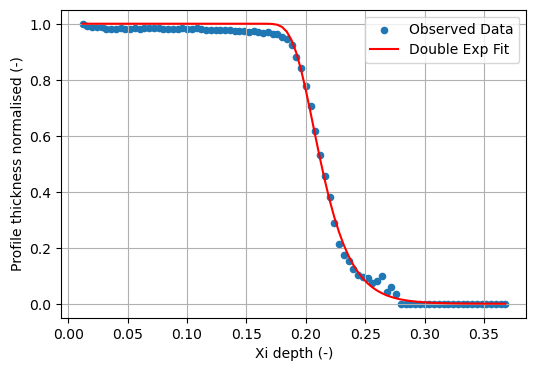

In [ ]:
fitter = FitModule()
popt, results = fitter.fit_profile(
    xi_obs,
    theta_obs,
    model_type=ModelType.DOUBLE_EXP_STABLE,  # slightly different verion of the double exponential model that is more stable for fitting
    ald_type=ALDType.THERMAL                 # alternatively, ALDType.PLASMA can be used for plasma-enhanced ALD
)

s0_from_double_exp = results["sticking_prob"]
print("\nParameter estimation results from Double exponential fit:")
print(results)

plot_double_exponential_fit(xi_obs,
                            theta_obs,
                            popt,
                            )

We note that Puurunen for this full dataset estimated a sticking probability of $5.02 \times 10^{-3}$, so our estimtate is not far off at all.